# Exploratory Data Analysis (EDA) on Loan Application Data

In [108]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
%pip install -q missingno 
import missingno as msno

Note: you may need to restart the kernel to use updated packages.


In [109]:
# Load the dataset
df = pd.read_excel('../Data/Data_finance_lab3.xlsx', sheet_name='data_final')
# Display basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   APP_ID                    5000 non-null   int64         
 1   DISBURSALDATE             5000 non-null   datetime64[ns]
 2   REPORT_DATE               5000 non-null   datetime64[ns]
 3   TERM_TMP                  5000 non-null   int64         
 4   PRODUCT_NAME              5000 non-null   object        
 5   LOANAMOUNT_NOT_INSURANCE  5000 non-null   int64         
 6   INSURANCE_FEE             5000 non-null   int64         
 7   LA                        5000 non-null   int64         
 8   EFF_RATE                  5000 non-null   float64       
 9   TERM                      5000 non-null   int64         
 10  COUNT_TERM_RECEIPT        4909 non-null   float64       
 11  flag term                 4909 non-null   float64       
 12  SUM_RECEIPT_AMT     

### Displaying the First Few Rows of the Dataset

In [110]:
df.head()

,APP_ID,DISBURSALDATE,REPORT_DATE,TERM_TMP,PRODUCT_NAME,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,LA,EFF_RATE,TERM,...,PERSONAL_INCOME,ADDITIONAL_INCOME,PERSONAL_EXPENSE,FAMILY_INCOME,FAMILY_EXPENSE,MARITAL_STATUS,EDUCATION,City,ADDRESS_CURRENT_CITY,PROVINCE_CURRENT
0,16499318,2017-10-10,2018-10-26,12,FC UP DSA TS SCORE 2 NEW- 762,18000000,990000,18990000,45.0,24,...,9000000,0,9600000,20000000,5000000,Other,High School,Tỉnh Yên Bái,Yên Bình,Tỉnh Yên Bái
1,16490594,2017-10-10,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,10000000,550000,10550000,44.5,12,...,5500000,0,7200000,15000000,4000000,Married,High School,Tỉnh Quảng Ninh,Đông Triều,Tỉnh Quảng Ninh
2,16910227,2017-10-28,2018-10-26,11,FC UP CAT B NEW- 610,25000000,1375000,26375000,47.0,24,...,5182000,0,12000000,5200000,1000000,Single,Middle School,Tỉnh Bình Dương,Tân Uyên,Tỉnh Bình Dương
3,16355347,2017-10-04,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,30000000,1650000,31650000,44.5,24,...,10000000,0,18000000,20000000,6000000,Married,Middle School,Tỉnh An Giang,Phú Tân,Tỉnh An Giang
4,16705974,2017-10-18,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,20000000,1100000,21100000,44.5,18,...,7000000,0,12000000,20000000,7000000,Single,High School,Thành phố Hải Phòng,Vĩnh Bảo,Thành phố Hải Phòng


In [111]:
df.columns  

Index(['APP_ID', 'DISBURSALDATE', 'REPORT_DATE', 'TERM_TMP', 'PRODUCT_NAME',
       'LOANAMOUNT_NOT_INSURANCE', 'INSURANCE_FEE', 'LA', 'EFF_RATE', 'TERM',
       'COUNT_TERM_RECEIPT', 'flag term', 'SUM_RECEIPT_AMT', 'Unnamed: 13',
       'flag loan amt', 'flag final', 'RESULT_YES/NO', 'EMI', 'GENDER', 'AGE',
       'Number of Children', 'PERSONAL_INCOME', 'ADDITIONAL_INCOME',
       'PERSONAL_EXPENSE', 'FAMILY_INCOME', 'FAMILY_EXPENSE', 'MARITAL_STATUS',
       'EDUCATION', 'City', 'ADDRESS_CURRENT_CITY', 'PROVINCE_CURRENT'],
      dtype='object')

### Missing Values Analysis

In [112]:
df['flag loan amt'].isnull().sum

<bound method NDFrame._add_numeric_operations.<locals>.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Name: flag loan amt, Length: 5000, dtype: bool>

<Axes: >

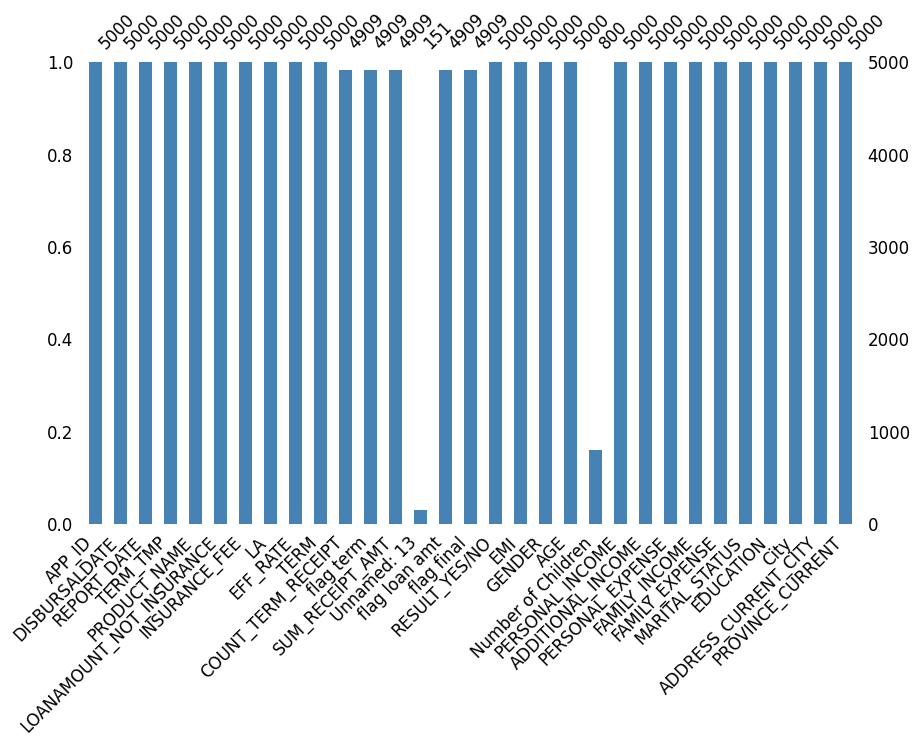

In [113]:
%matplotlib inline
msno.bar(df, figsize=(10, 6), fontsize=12, color='steelblue', )

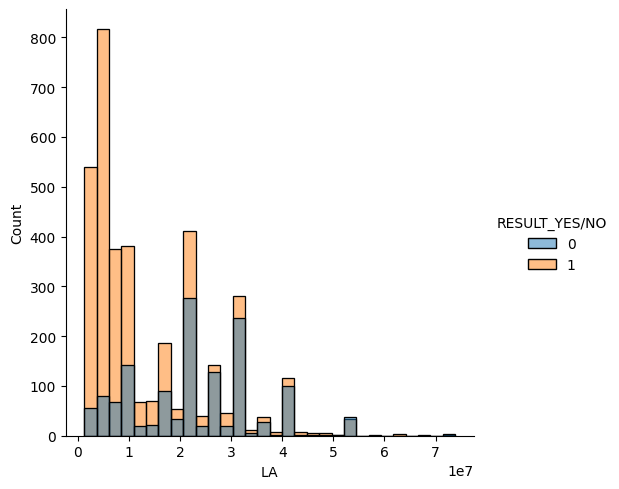

In [131]:
sns.displot(data=df, x='LA', hue='RESULT_YES/NO')

### Outliers

In [122]:
numerical_df = df.select_dtypes(include=['float64', 'int64'])
categorical_df = df[['GENDER', 'MARITAL_STATUS', 'EDUCATION', 'PRODUCT_NAME']]

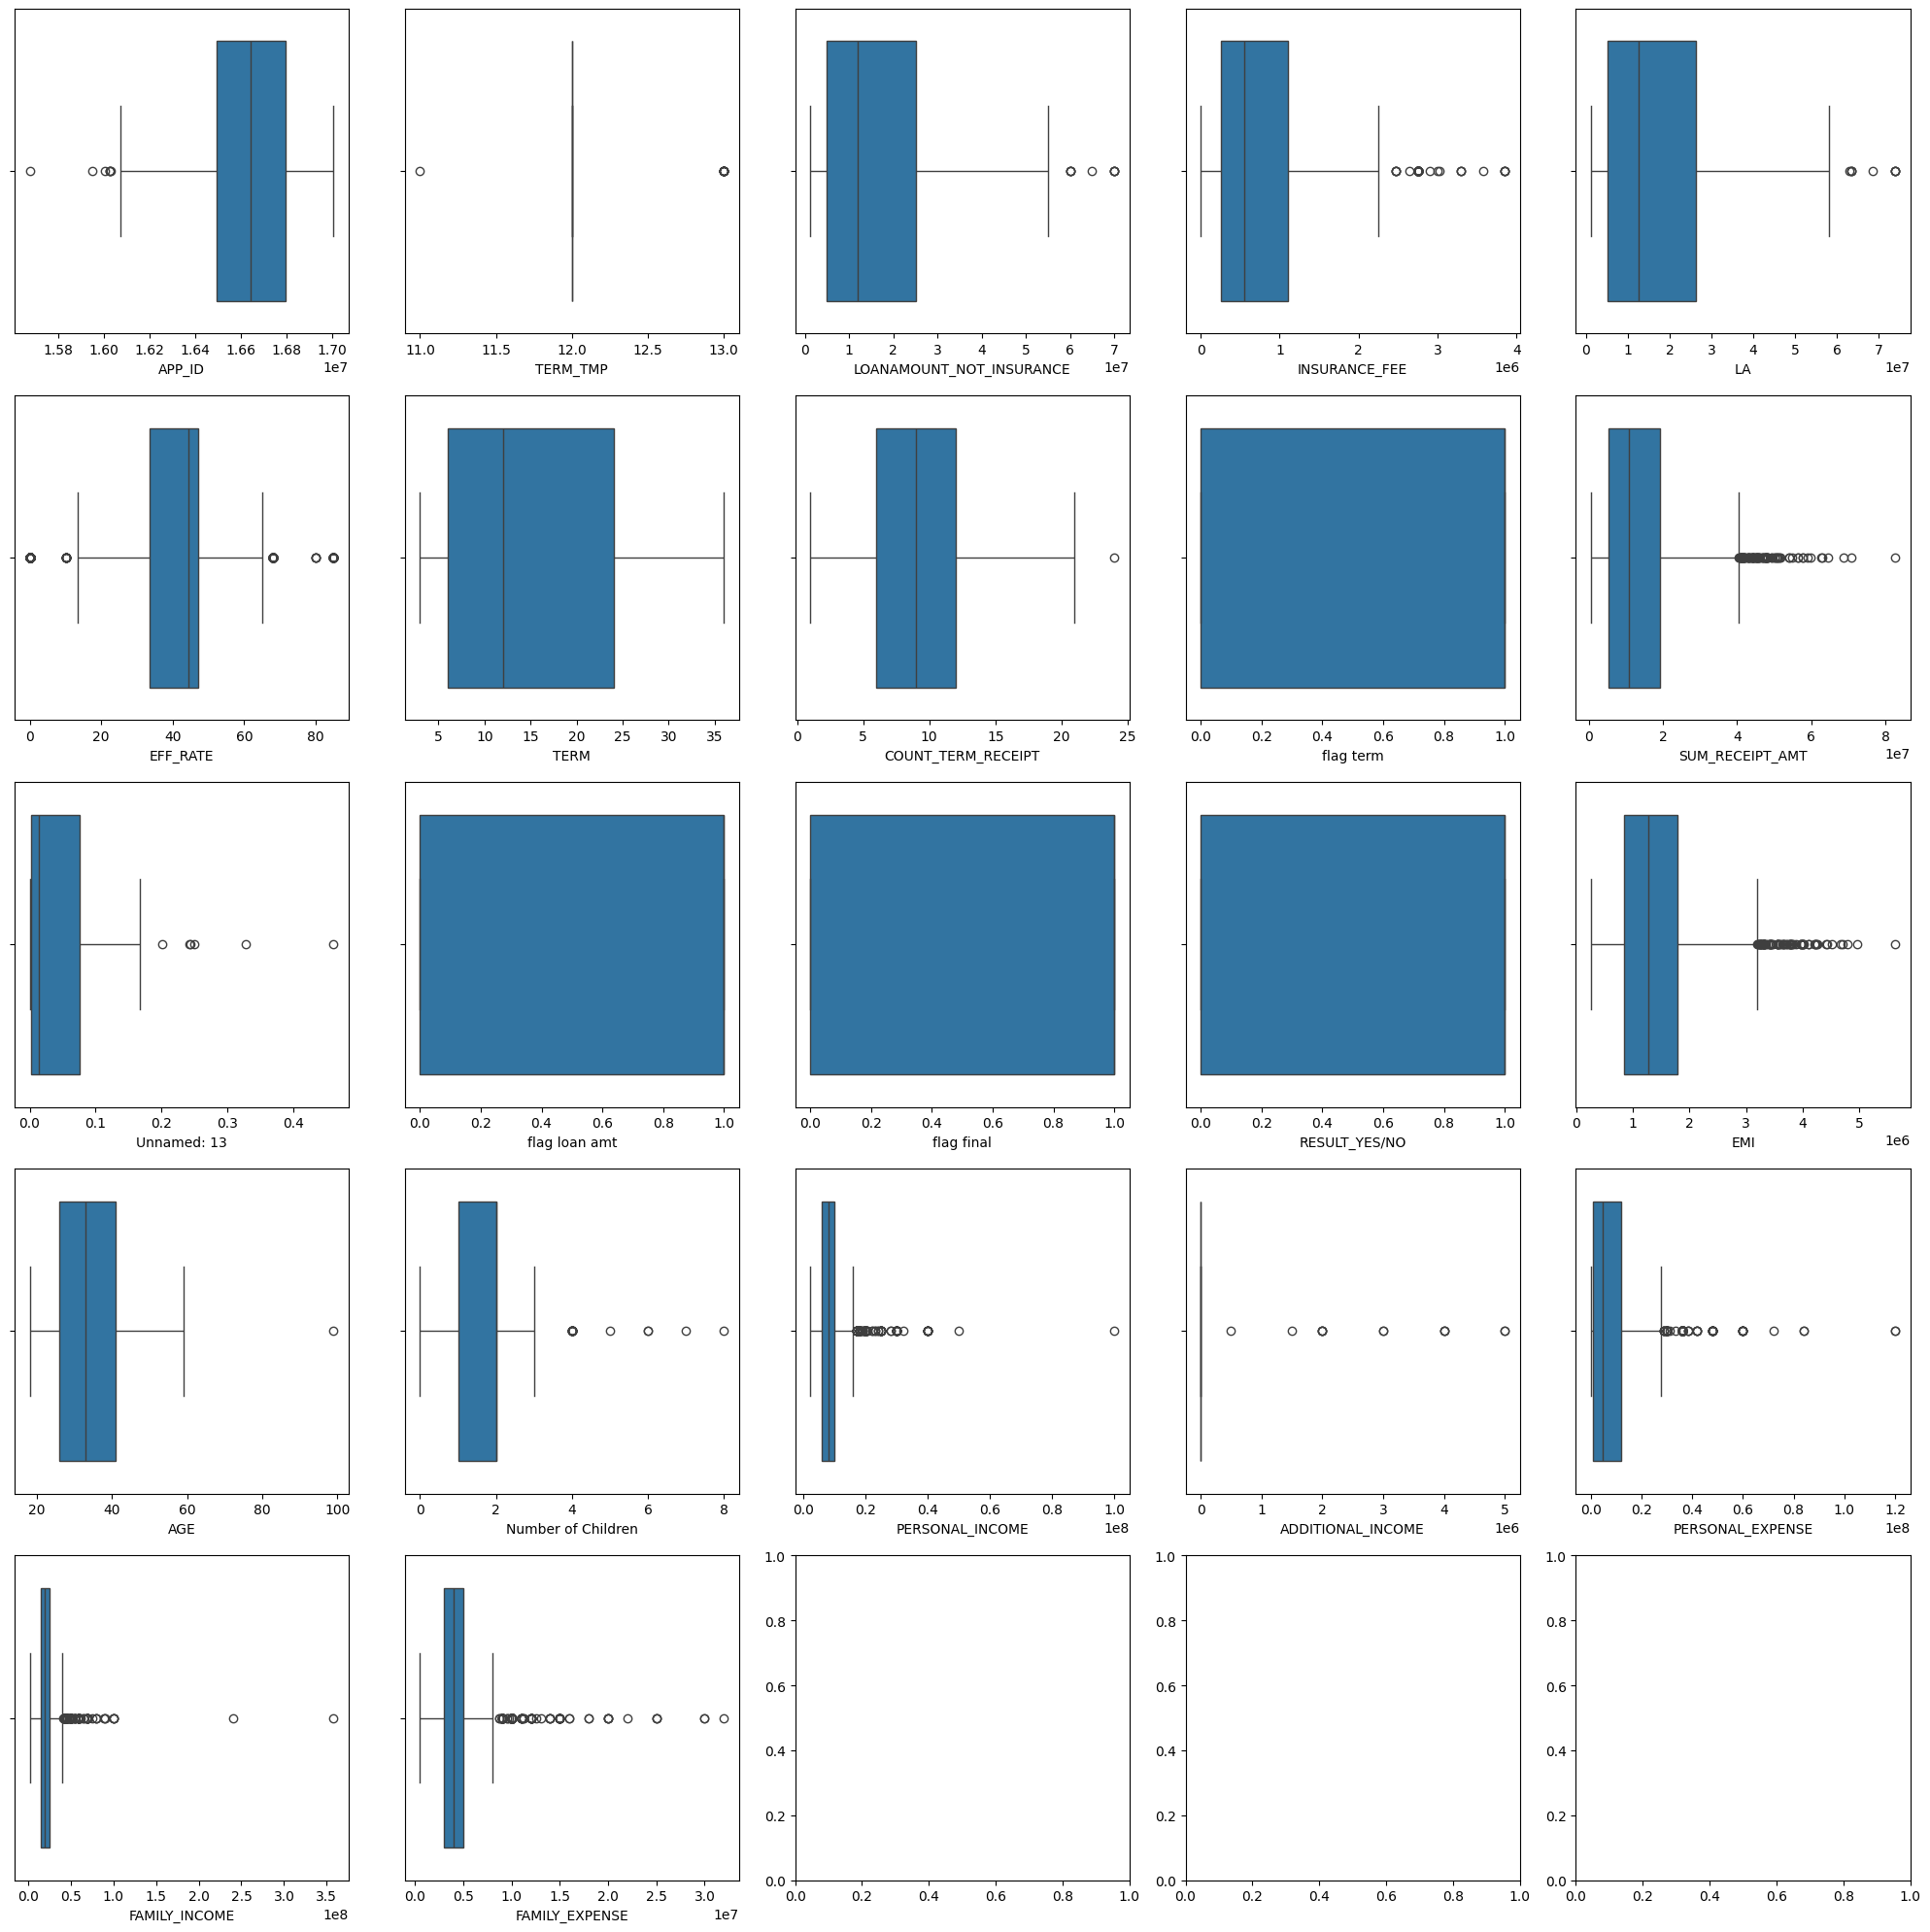

In [123]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(20, 20))
axes = axes.flatten()
for i, num in enumerate(numerical_df.columns):
    sns.boxplot(data=numerical_df, x=num, ax=axes[i])
plt.tight_layout()
plt.show()

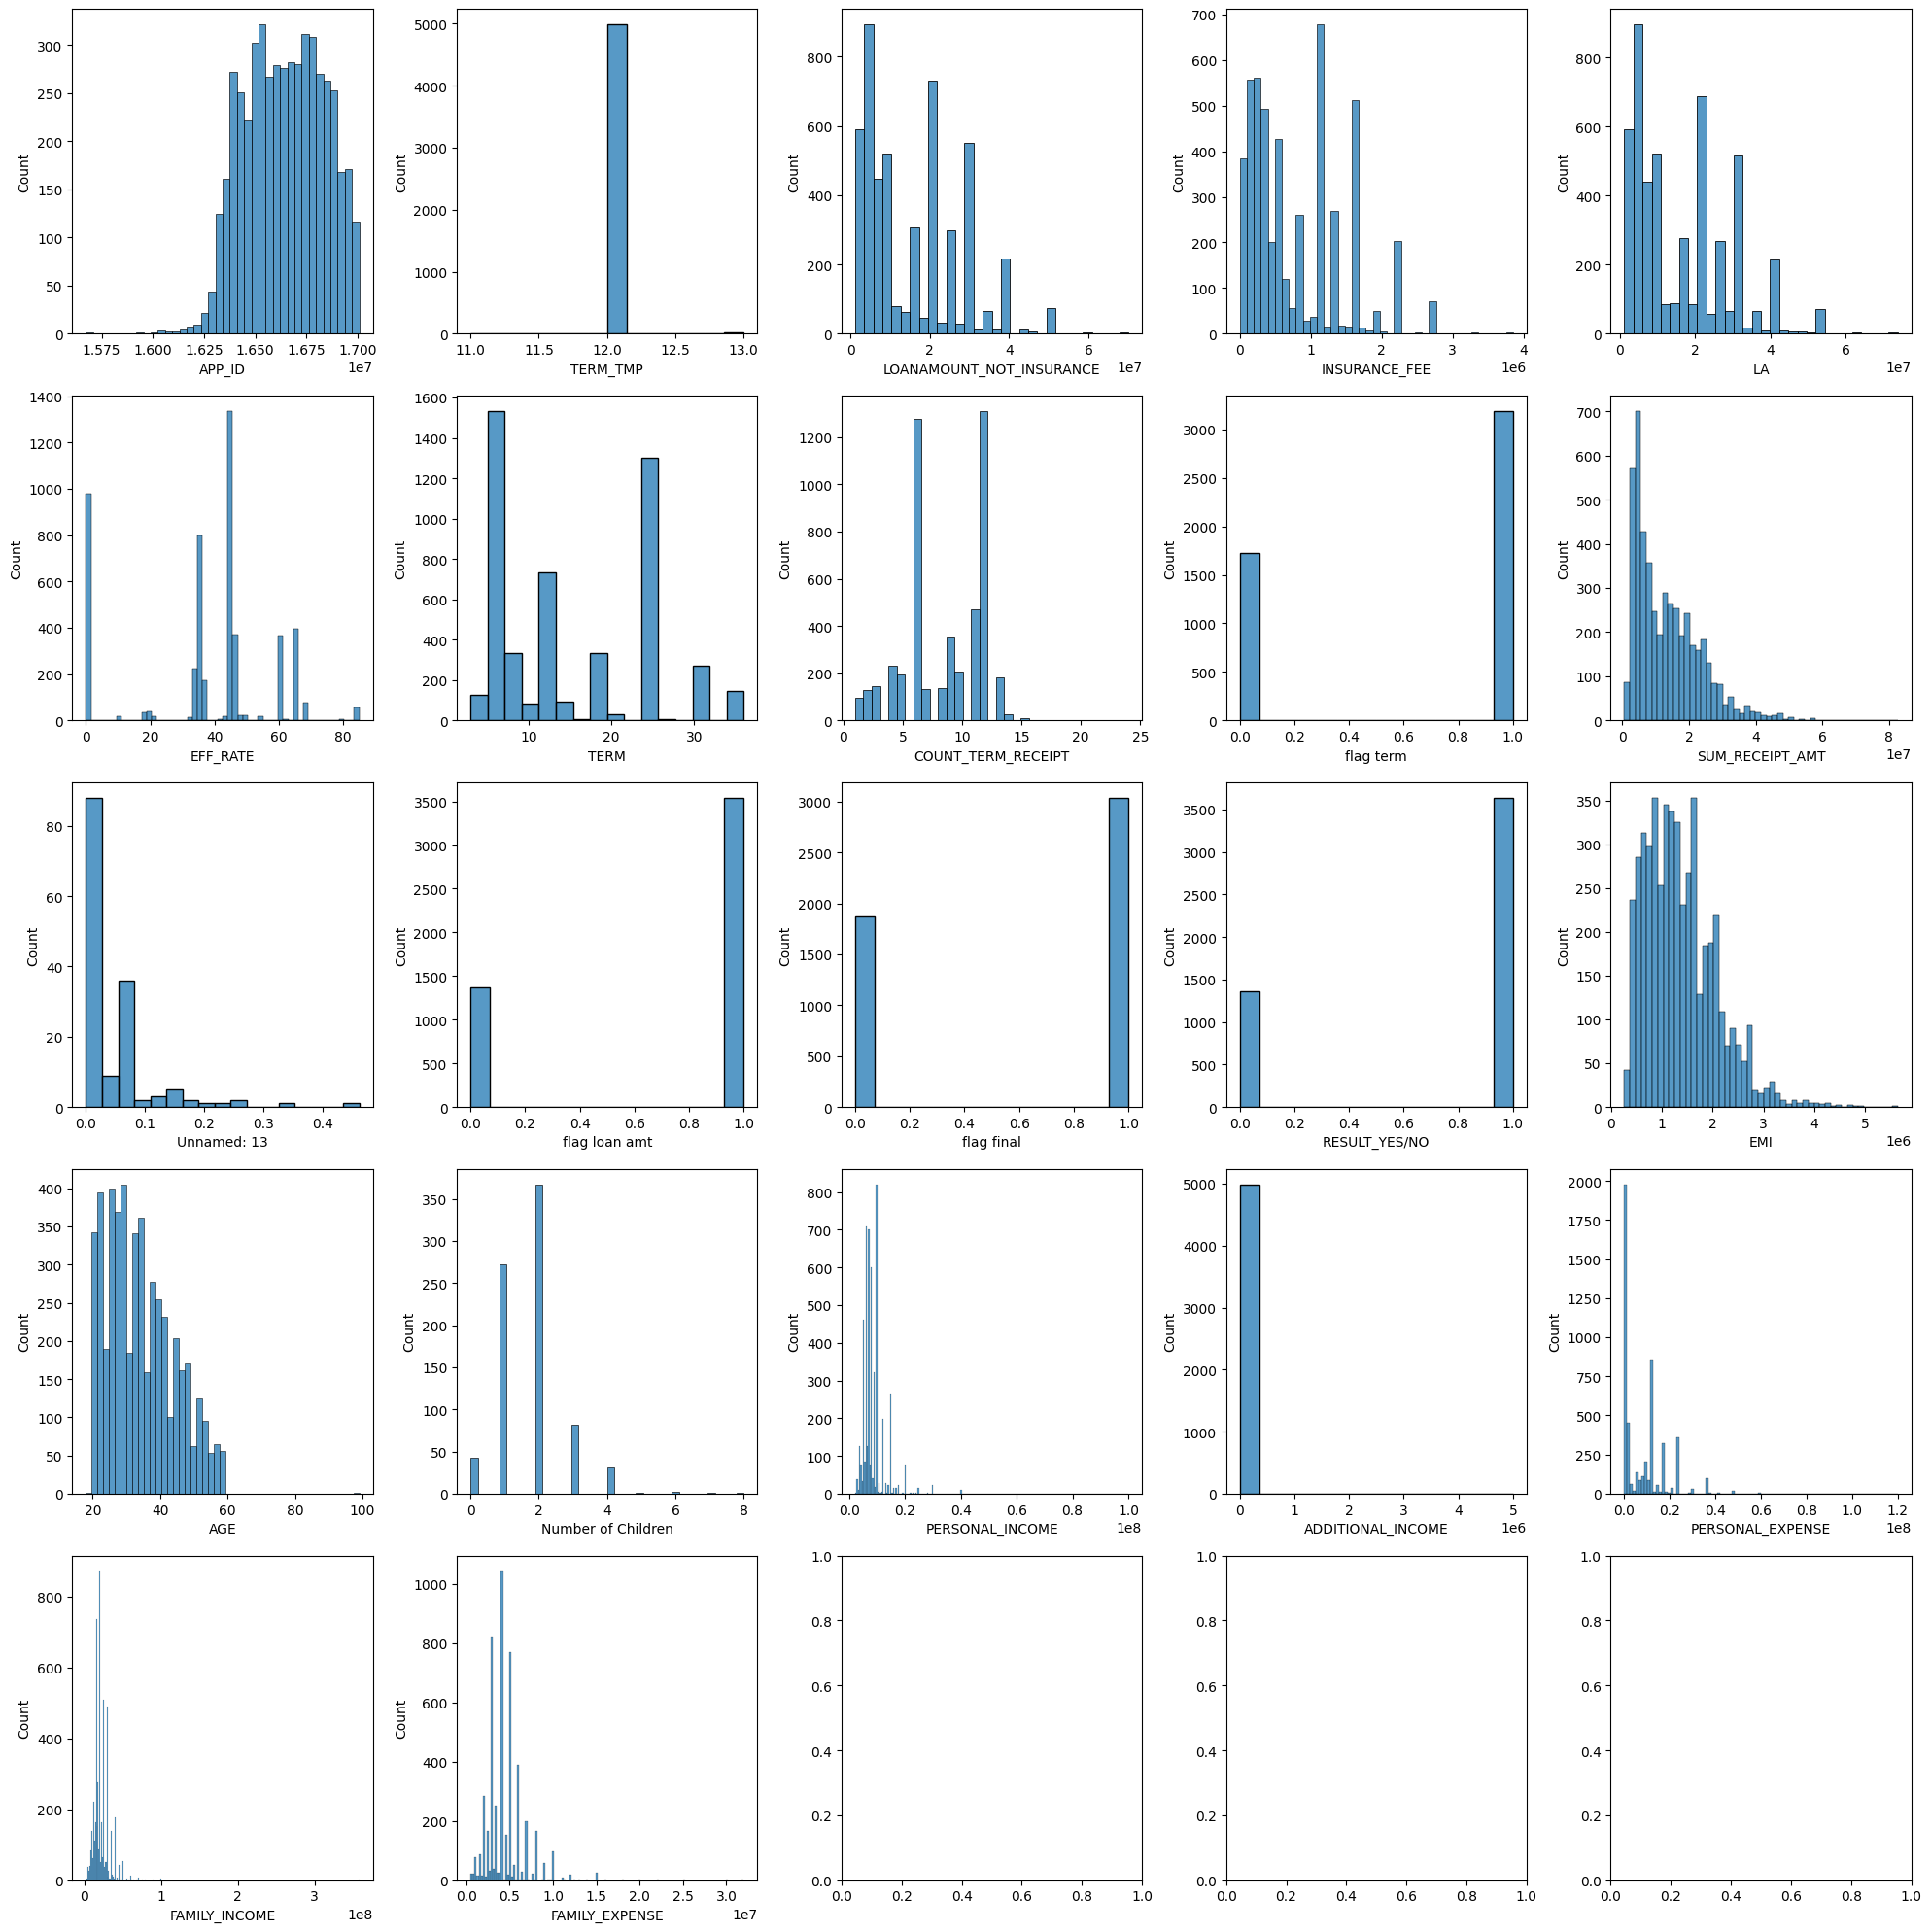

In [124]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(20, 20))
axes = axes.flatten()
for i, num in enumerate(numerical_df.columns):
    sns.histplot(data=numerical_df, x=num, ax=axes[i])
plt.tight_layout()
plt.show()

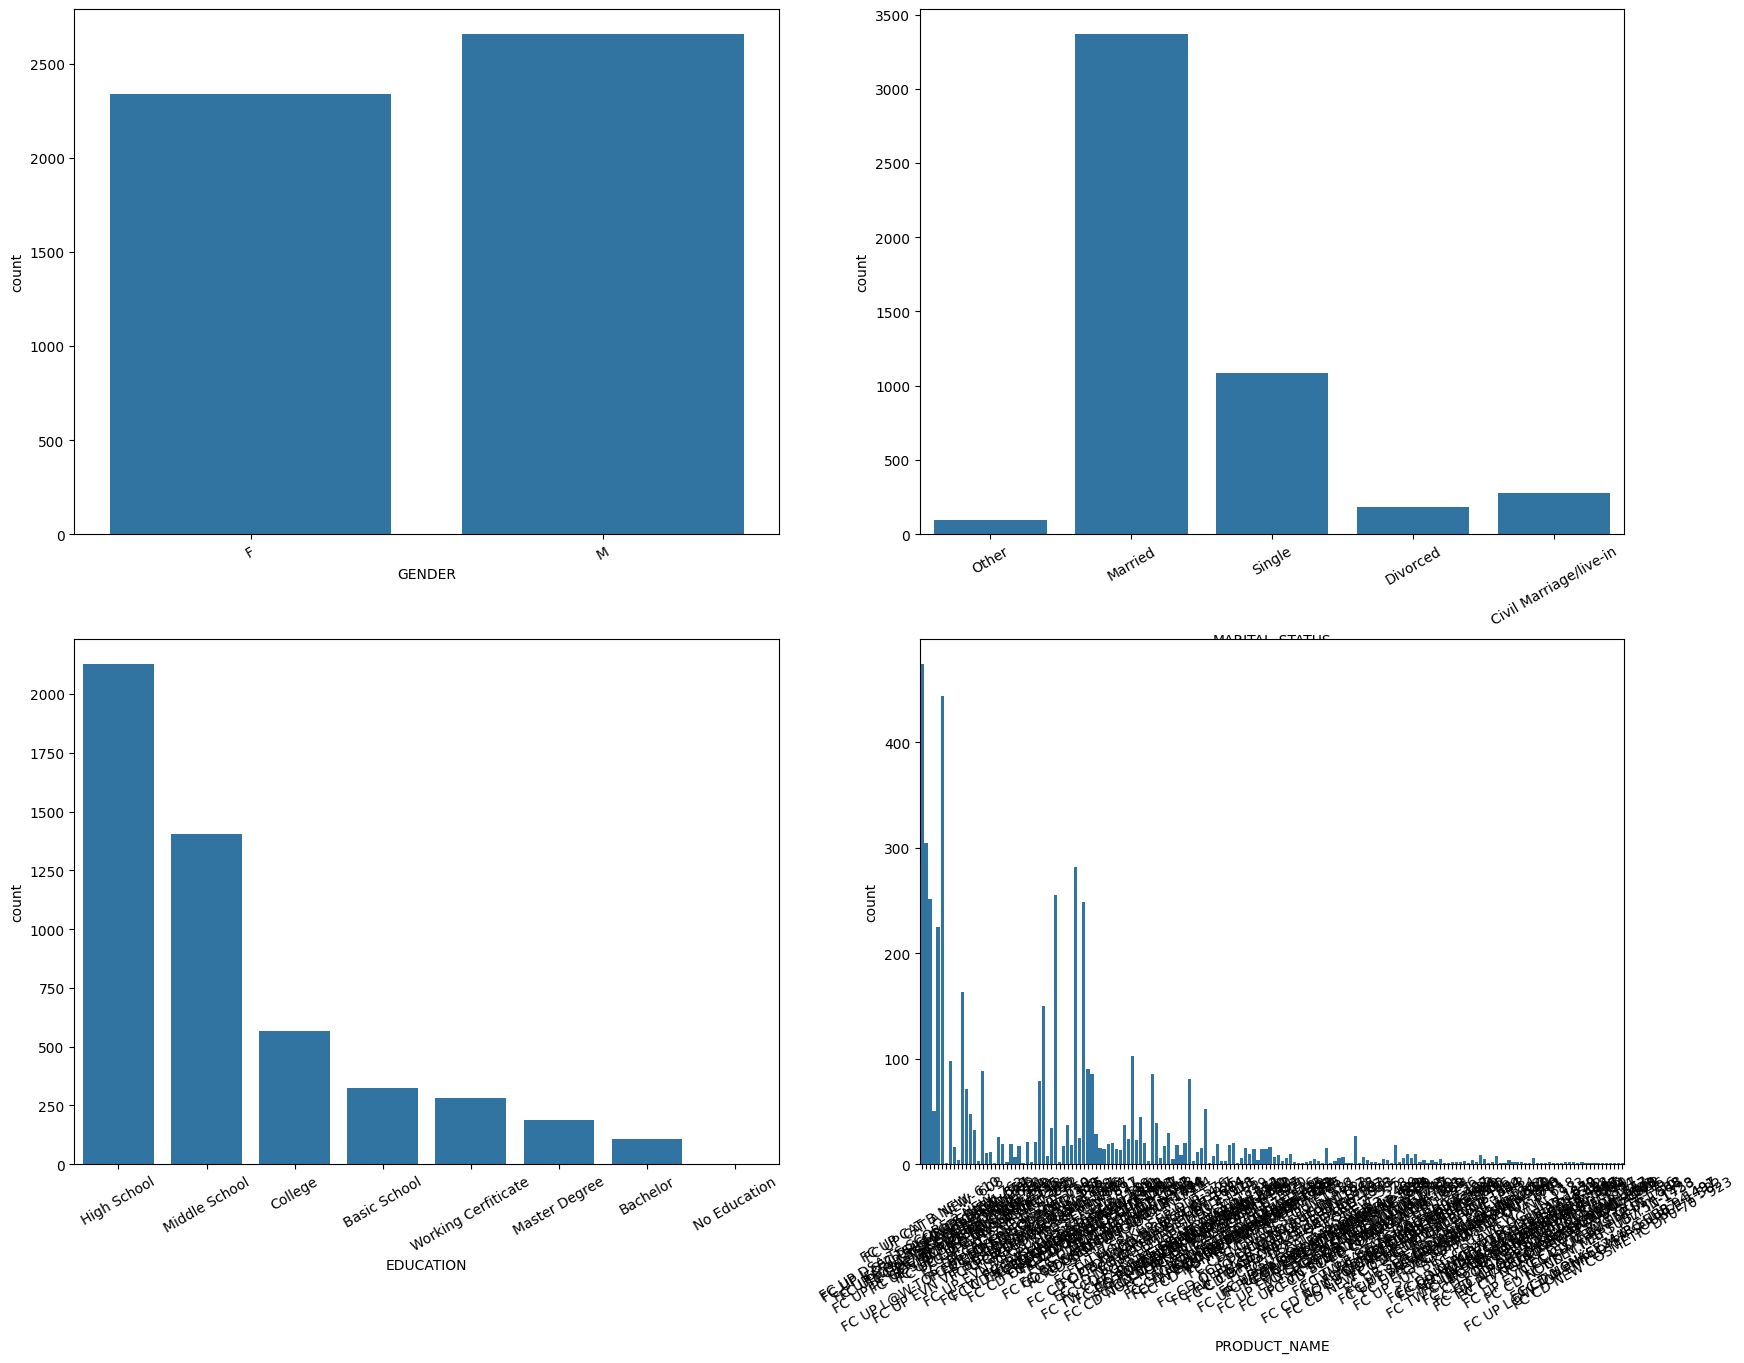

In [125]:
fig = plt.figure(figsize = (20,15))
axes = 220
for cat in categorical_df.columns:
    axes += 1
    fig.add_subplot(axes)
    sns.countplot(data = categorical_df, x = cat)
    plt.xticks(rotation=30)
plt.show()

### Summary Statistics of Numerical Columns

In [118]:
numerical_df.describe()

,APP_ID,TERM_TMP,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,LA,EFF_RATE,TERM,COUNT_TERM_RECEIPT,flag term,SUM_RECEIPT_AMT,...,flag final,RESULT_YES/NO,EMI,AGE,Number of Children,PERSONAL_INCOME,ADDITIONAL_INCOME,PERSONAL_EXPENSE,FAMILY_INCOME,FAMILY_EXPENSE
count,5.000000e+03,5000.000000,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4909.000000,4909.000000,4.909000e+03,...,4909.000000,5000.000000,5.000000e+03,5000.000000,800.000000,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03
mean,1.664263e+07,12.003200,1.564802e+07,7.934629e+05,1.644148e+07,36.797372,15.046800,8.464046,0.649216,1.339056e+07,...,0.618456,0.727200,1.373196e+06,34.283000,1.760000,8.563299e+06,7.600000e+03,8.464034e+06,2.180893e+07,4.473954e+06
std,1.892634e+05,0.059921,1.196323e+07,6.654844e+05,1.255701e+07,21.158261,8.907776,3.369312,0.477264,9.832199e+06,...,0.485815,0.445443,6.898423e+05,9.898874,0.939949,4.176414e+06,1.638524e+05,9.692969e+06,1.124716e+07,2.307437e+06
min,1.567386e+07,11.000000,1.200000e+06,0.000000e+00,1.260000e+06,0.000000,3.000000,1.000000,0.000000,6.400000e+05,...,0.000000,0.000000,2.660000e+05,18.000000,0.000000,2.200000e+06,0.000000e+00,2.000000e+05,2.000000e+06,5.000000e+05
25%,1.649293e+07,12.000000,4.940000e+06,2.536380e+05,5.215938e+06,33.500000,6.000000,6.000000,0.000000,5.292000e+06,...,0.000000,0.000000,8.435000e+05,26.000000,1.000000,6.000000e+06,0.000000e+00,1.000000e+06,1.500000e+07,3.000000e+06
50%,1.664363e+07,12.000000,1.200000e+07,5.500000e+05,1.266000e+07,44.500000,12.000000,9.000000,1.000000,1.091600e+07,...,1.000000,1.000000,1.278378e+06,33.000000,2.000000,8.000000e+06,0.000000e+00,4.900000e+06,2.000000e+07,4.000000e+06
75%,1.679488e+07,12.000000,2.500000e+07,1.100000e+06,2.637500e+07,47.000000,24.000000,12.000000,1.000000,1.931300e+07,...,1.000000,1.000000,1.785462e+06,41.000000,2.000000,1.000000e+07,0.000000e+00,1.200000e+07,2.500000e+07,5.000000e+06
max,1.700631e+07,13.000000,7.000000e+07,3.850000e+06,7.385000e+07,85.000000,36.000000,24.000000,1.000000,8.252572e+07,...,1.000000,1.000000,5.632000e+06,99.000000,8.000000,1.000000e+08,5.000000e+06,1.200000e+08,3.580000e+08,3.200000e+07


### Correlation Heatmap

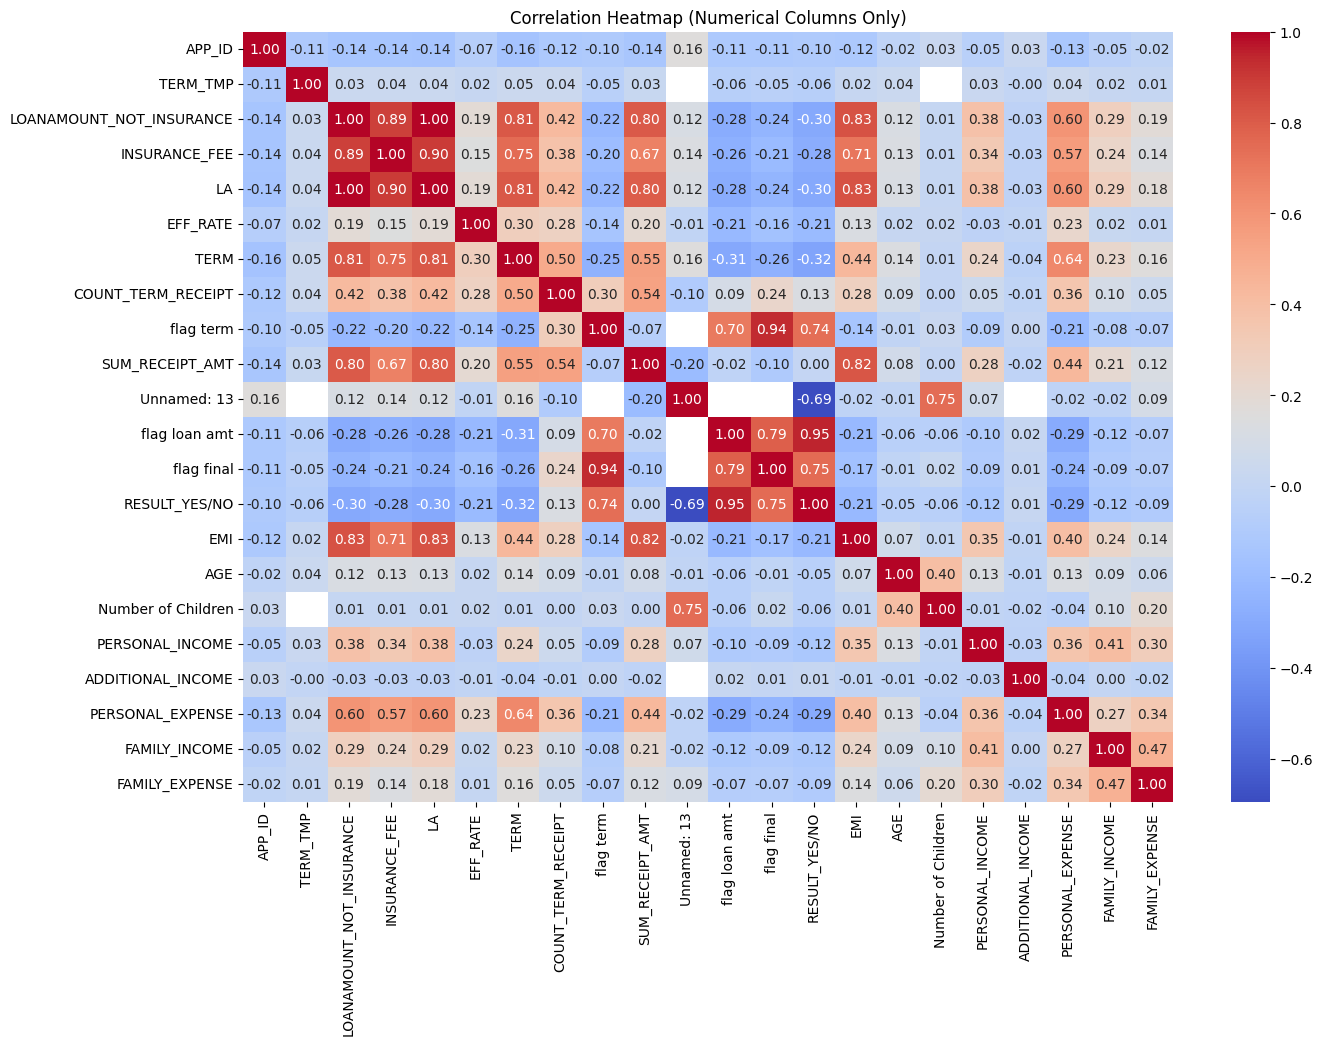

In [119]:
# Updated Correlation Heatmap with Only Numerical Columns

plt.figure(figsize=(15, 10))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numerical Columns Only)')
plt.show()

<Axes: >

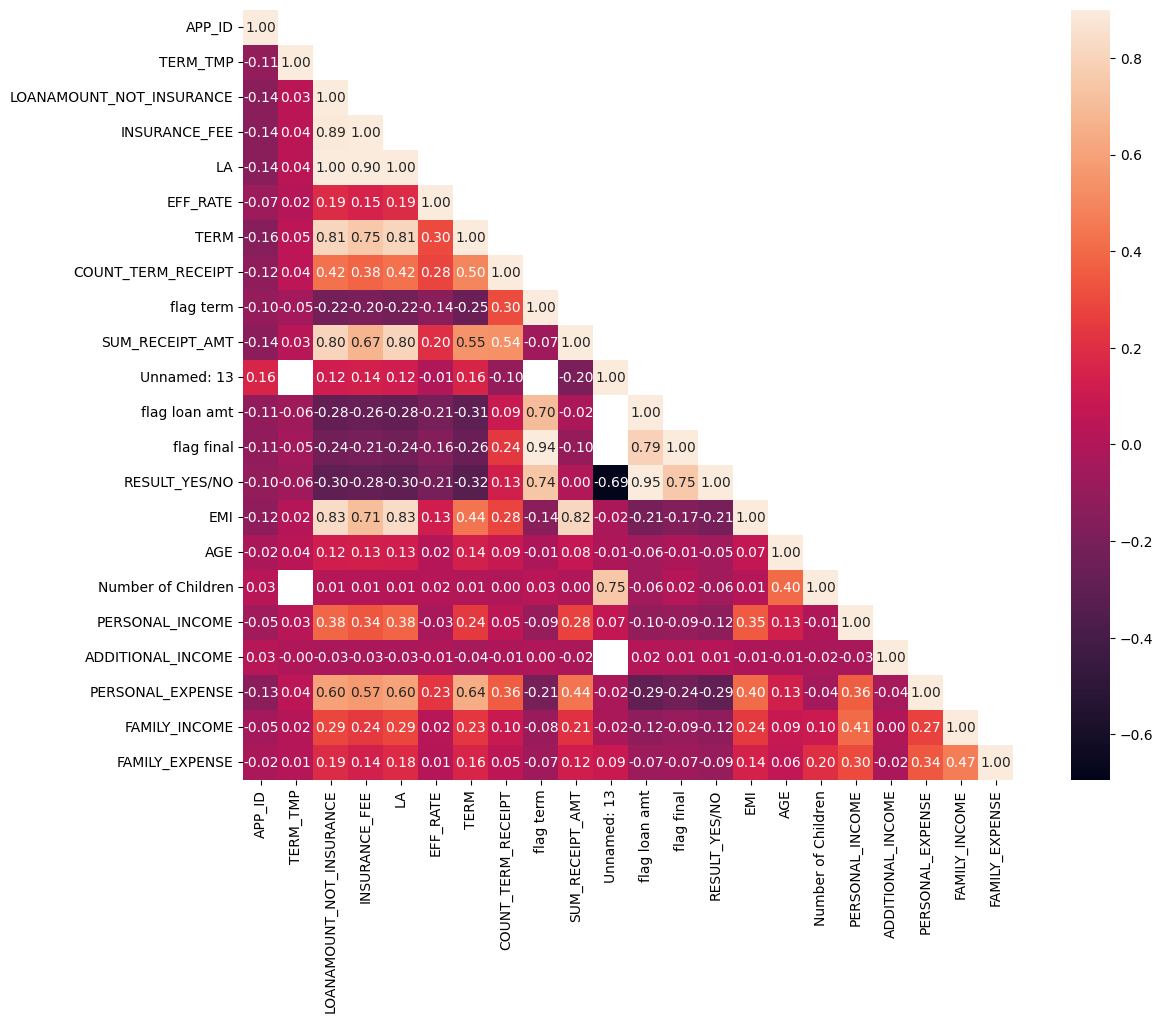

In [120]:
#create correlation
corr = numerical_df.corr(method = 'pearson')

#convert correlation to numpy array
mask = np.array(corr)

#to mask the repetitive value for each pair
mask[np.tril_indices_from(mask)] = False
fig, ax = plt.subplots(figsize = (10,10))
fig.set_size_inches(15,10)
sns.heatmap(corr, mask = mask, vmax = 0.9, square = True, annot = True, fmt='.2f')

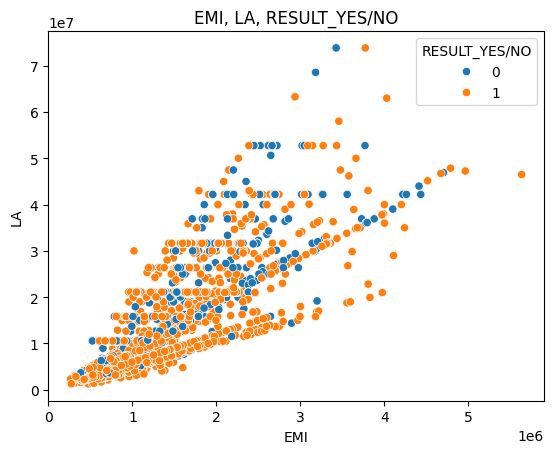

In [130]:
sns.scatterplot(x=df['EMI'], y= df['LA'], hue=df['RESULT_YES/NO'])
plt.title("EMI, LA, RESULT_YES/NO")
plt.xlabel("EMI")
plt.ylabel("LA")
plt.show()